# BraTS 2021 (Task 1) — Dataset Setup & EDA


## Step 1 — Install dependencies

In [1]:
# Only what's needed to read NIfTI volumes and do the EDA below.
!pip install -q nibabel tqdm --no-deps

import nibabel as nib
print("nibabel:", nib.__version__)


nibabel: 5.4.2


## Imports

In [2]:
import glob
import os
import tarfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm


## Dataset path

In [3]:
brats_root = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"
brats_extract_dir = "/kaggle/working/brats2021"

print("BraTS root contents:", os.listdir(brats_root)[:5])


BraTS root contents: ['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


## Extract BraTS2021 (packaged as `.tar` archives, ~13.4 GB uncompressed — fits Kaggle scratch disk)

In [4]:
os.makedirs(brats_extract_dir, exist_ok=True)

tar_files = glob.glob(f"{brats_root}/*.tar")
print(f"Found {len(tar_files)} tar files:", [os.path.basename(t) for t in tar_files])

for tar_path in tar_files:
    print(f"Extracting {os.path.basename(tar_path)} ...")
    with tarfile.open(tar_path, "r") as tf:
        for member in tqdm(tf.getmembers(), desc=os.path.basename(tar_path)):
            tf.extract(member, brats_extract_dir)

n_extracted = sum(len(files) for _, _, files in os.walk(brats_extract_dir))
print("Done. Total files extracted:", n_extracted)

total_gb = sum(os.path.getsize(t) for t in tar_files) / 1e9
print(f"{len(tar_files)} tar files, {total_gb:.1f} GB total (compressed/on-disk size)")


Found 3 tar files: ['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']
Extracting BraTS2021_00495.tar ...


BraTS2021_00495.tar:   0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_58/1524565714.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(member, brats_extract_dir)
BraTS2021_00495.tar: 100%|██████████| 6/6 [00:00<00:00, 57.86it/s]


Extracting BraTS2021_Training_Data.tar ...


BraTS2021_Training_Data.tar: 100%|██████████| 7508/7508 [00:55<00:00, 134.35it/s]


Extracting BraTS2021_00621.tar ...


BraTS2021_00621.tar: 100%|██████████| 6/6 [00:00<00:00, 111.51it/s]

Done. Total files extracted: 6266
3 tar files, 13.4 GB total (compressed/on-disk size)


## Sanity check — load one sample volume

In [5]:
sample_t1ce = glob.glob(f"{brats_extract_dir}/**/*_t1ce.nii.gz", recursive=True)[0]
img = nib.load(sample_t1ce)
print("Sample file:", sample_t1ce)
print("BraTS T1CE shape/spacing:", img.shape, img.header.get_zooms())


Sample file: /kaggle/working/brats2021/BraTS2021_00495_t1ce.nii.gz
BraTS T1CE shape/spacing: (240, 240, 155) (np.float32(1.0), np.float32(1.0), np.float32(1.0))


## EDA: case discovery & modality completeness

BraTS2021 stores each case as its own folder with up to five files:
`t1`, `t1ce`, `t2`, `flair`, and `seg` (segmentation labels — only present for the
training split, not validation). We discover every case from its `flair` file (present
in every split), then check which of the other modalities exist alongside it.

In [6]:
MODALITIES = ["t1", "t1ce", "t2", "flair", "seg"]

flair_files = sorted(glob.glob(f"{brats_extract_dir}/**/*_flair.nii.gz", recursive=True))
print(f"Found {len(flair_files)} cases (based on *_flair.nii.gz files).")

records = []
for flair_path in flair_files:
    case_dir = os.path.dirname(flair_path)
    case_id = os.path.basename(flair_path).replace("_flair.nii.gz", "")
    row = {"case_id": case_id, "case_dir": case_dir}
    for mod in MODALITIES:
        row[mod] = os.path.exists(os.path.join(case_dir, f"{case_id}_{mod}.nii.gz"))
    records.append(row)

cases_df = pd.DataFrame(records)
print("\nModality completeness (count of cases where the file is present):")
print(cases_df[MODALITIES].sum())

print("\nCases missing any modality:")
incomplete = cases_df[~cases_df[MODALITIES].all(axis=1)]
print(incomplete[["case_id"] + MODALITIES] if len(incomplete) else "None — every case has all 5 files.")

cases_with_seg = cases_df[cases_df["seg"]].reset_index(drop=True)
print(f"\n{len(cases_with_seg)} / {len(cases_df)} cases have a segmentation label (training split).")


Found 1253 cases (based on *_flair.nii.gz files).

Modality completeness (count of cases where the file is present):
t1       1253
t1ce     1253
t2       1253
flair    1253
seg      1253
dtype: int64

Cases missing any modality:
None — every case has all 5 files.

1253 / 1253 cases have a segmentation label (training split).


## EDA: image geometry consistency

Checks the voxel array shape and voxel spacing for every case's T1CE volume (header-only
read via `nibabel`, so this is cheap even across the full dataset) and flags anything that
doesn't match the dataset's expected `(240, 240, 155)` / `1mm` isotropic convention.

In [7]:
shape_counter = Counter()
spacing_counter = Counter()
geometry_outliers = []

for _, row in tqdm(cases_df.iterrows(), total=len(cases_df), desc="Checking geometry"):
    t1ce_path = os.path.join(row["case_dir"], f"{row['case_id']}_t1ce.nii.gz")
    if not os.path.exists(t1ce_path):
        continue
    hdr_img = nib.load(t1ce_path)
    shape = hdr_img.shape
    spacing = tuple(round(z, 2) for z in hdr_img.header.get_zooms())
    shape_counter[shape] += 1
    spacing_counter[spacing] += 1
    if shape != (240, 240, 155):
        geometry_outliers.append({"case_id": row["case_id"], "shape": shape, "spacing": spacing})

print("Shape distribution across all cases:")
for shape, count in shape_counter.most_common():
    print(f"  {shape}: {count}")

print("\nVoxel spacing distribution across all cases:")
for spacing, count in spacing_counter.most_common():
    print(f"  {spacing}: {count}")

print(f"\nCases with non-standard shape: {len(geometry_outliers)}")
if geometry_outliers:
    print(pd.DataFrame(geometry_outliers))


Checking geometry: 100%|██████████| 1253/1253 [00:02<00:00, 567.31it/s]

Shape distribution across all cases:
  (240, 240, 155): 1253

Voxel spacing distribution across all cases:
  (np.float32(1.0), np.float32(1.0), np.float32(1.0)): 1253

Cases with non-standard shape: 0


## EDA: segmentation label distribution

BraTS labels: `0` = background, `1` = necrotic tumor core (NCR), `2` = peritumoral
edematous/invaded tissue (ED), `4` = GD-enhancing tumor (ET). This loads every
segmentation mask in the training split and tallies voxel counts per label.

Set `SAMPLE_SIZE` to an integer (e.g. `100`) to run on a quick subset first; leave it as
`None` to scan the full training split.

Scanning segmentation masks: 100%|██████████| 1253/1253 [03:36<00:00,  5.79it/s]


Scanned 1253 cases.

Total voxel counts across all scanned cases:
  0 (background): 11,066,602,367
  1 (necrotic core (NCR)): 17,917,204
  2 (edema (ED)): 75,397,999
  4 (enhancing tumor (ET)): 26,866,430

Fraction of cases containing each tumor sub-region:
has_label_1    0.964884
has_label_2    0.999202
has_label_4    0.973663
dtype: float64


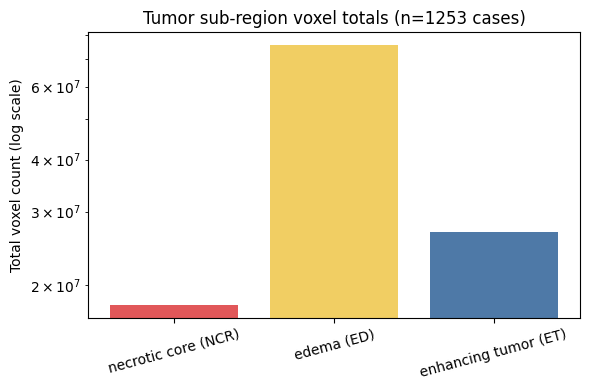

In [8]:
SAMPLE_SIZE = None  # e.g. 100 for a quick pass, or None for all cases_with_seg

label_names = {0: "background", 1: "necrotic core (NCR)", 2: "edema (ED)", 4: "enhancing tumor (ET)"}
subset = cases_with_seg if SAMPLE_SIZE is None else cases_with_seg.head(SAMPLE_SIZE)

voxel_totals = Counter()
per_case_label_presence = []

for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Scanning segmentation masks"):
    seg_path = os.path.join(row["case_dir"], f"{row['case_id']}_seg.nii.gz")
    seg = nib.load(seg_path).get_fdata()
    labels, counts = np.unique(seg, return_counts=True)
    case_labels = dict(zip(labels.astype(int), counts))
    for lbl, cnt in case_labels.items():
        voxel_totals[lbl] += cnt
    per_case_label_presence.append({
        "case_id": row["case_id"],
        **{f"has_label_{lbl}": (lbl in case_labels and lbl != 0) for lbl in [1, 2, 4]},
    })

print(f"Scanned {len(subset)} cases.\n")
print("Total voxel counts across all scanned cases:")
for lbl in sorted(voxel_totals):
    name = label_names.get(lbl, f"label {lbl}")
    print(f"  {lbl} ({name}): {int(voxel_totals[lbl]):,}")

presence_df = pd.DataFrame(per_case_label_presence)
print("\nFraction of cases containing each tumor sub-region:")
print(presence_df[["has_label_1", "has_label_2", "has_label_4"]].mean())

fig, ax = plt.subplots(figsize=(6, 4))
tumor_labels = [1, 2, 4]
tumor_counts = [voxel_totals.get(l, 0) for l in tumor_labels]
ax.bar([label_names[l] for l in tumor_labels], tumor_counts, color=["#e15759", "#f1ce63", "#4e79a7"])
ax.set_ylabel("Total voxel count (log scale)")
ax.set_yscale("log")
ax.set_title(f"Tumor sub-region voxel totals (n={len(subset)} cases)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## EDA: tumor volume per patient

Whole-tumor volume (all non-zero labels) per case, converted from voxel counts to cm³
using each volume's voxel spacing. Reuses the same `subset` scanned above.

In [ ]:
volume_records = []

for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Computing tumor volumes"):
    seg_path = os.path.join(row["case_dir"], f"{row['case_id']}_seg.nii.gz")
    seg_img = nib.load(seg_path)
    seg = seg_img.get_fdata()
    zooms = seg_img.header.get_zooms()
    voxel_vol_mm3 = zooms[0] * zooms[1] * zooms[2]

    tumor_voxels = int(np.count_nonzero(seg))
    et_voxels = int(np.count_nonzero(seg == 4))
    ed_voxels = int(np.count_nonzero(seg == 2))
    ncr_voxels = int(np.count_nonzero(seg == 1))

    volume_records.append({
        "case_id": row["case_id"],
        "whole_tumor_cm3": tumor_voxels * voxel_vol_mm3 / 1000,
        "enhancing_tumor_cm3": et_voxels * voxel_vol_mm3 / 1000,
        "edema_cm3": ed_voxels * voxel_vol_mm3 / 1000,
        "necrotic_core_cm3": ncr_voxels * voxel_vol_mm3 / 1000,
    })

volume_df = pd.DataFrame(volume_records)
print(volume_df.describe())

fig, ax = plt.subplots(figsize=(7, 4))
volume_df["whole_tumor_cm3"].plot(kind="hist", bins=30, ax=ax, color="#4e79a7")
ax.set_xlabel("Whole tumor volume (cm³)")
ax.set_title(f"Distribution of whole-tumor volume (n={len(volume_df)} cases)")
plt.tight_layout()
plt.show()


Computing tumor volumes:  50%|████▉     | 626/1253 [01:06<01:14,  8.44it/s]

## EDA: visualize a sample case (all modalities + segmentation overlay)

Picks the case with the largest whole-tumor volume from the scan above (falls back to the
first available case if the volume scan was skipped), finds its largest-tumor axial slice,
and plots all four MRI modalities alongside the raw segmentation mask and a T1CE+segmentation
overlay.

In [ ]:
if len(volume_df):
    sample_case_id = volume_df.loc[volume_df["whole_tumor_cm3"].idxmax(), "case_id"]
else:
    sample_case_id = cases_with_seg.iloc[0]["case_id"]

sample_row = cases_df[cases_df["case_id"] == sample_case_id].iloc[0]
case_dir = sample_row["case_dir"]

vols = {}
for mod in ["t1", "t1ce", "t2", "flair"]:
    vols[mod] = nib.load(os.path.join(case_dir, f"{sample_case_id}_{mod}.nii.gz")).get_fdata()
seg = nib.load(os.path.join(case_dir, f"{sample_case_id}_seg.nii.gz")).get_fdata()

# pick the axial slice with the most tumor voxels
tumor_per_slice = (seg > 0).sum(axis=(0, 1))
best_slice = int(np.argmax(tumor_per_slice))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Case {sample_case_id} — axial slice {best_slice}", fontsize=14)

for ax, mod in zip(axes.flat[:4], ["t1", "t1ce", "t2", "flair"]):
    ax.imshow(vols[mod][:, :, best_slice].T, cmap="gray", origin="lower")
    ax.set_title(mod.upper())
    ax.axis("off")

axes.flat[4].imshow(seg[:, :, best_slice].T, cmap="viridis", origin="lower", vmin=0, vmax=4)
axes.flat[4].set_title("Segmentation labels")
axes.flat[4].axis("off")

axes.flat[5].imshow(vols["t1ce"][:, :, best_slice].T, cmap="gray", origin="lower")
seg_masked = np.ma.masked_where(seg[:, :, best_slice].T == 0, seg[:, :, best_slice].T)
axes.flat[5].imshow(seg_masked, cmap="autumn", alpha=0.5, origin="lower", vmin=0, vmax=4)
axes.flat[5].set_title("T1CE + segmentation overlay")
axes.flat[5].axis("off")

plt.tight_layout()
plt.show()


## Save EDA summary tables

In [ ]:
cases_df.drop(columns="case_dir").to_csv("/kaggle/working/brats2021_case_completeness.csv", index=False)
volume_df.to_csv("/kaggle/working/brats2021_tumor_volumes.csv", index=False)
print("Saved:")
print(" - /kaggle/working/brats2021_case_completeness.csv")
print(" - /kaggle/working/brats2021_tumor_volumes.csv")
